In [58]:
# 1 Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas import DataFrame
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import confusion_matrix, recall_score, f1_score, precision_score


In [59]:
df = pd.read_csv("accident.csv")
df

,age,gender,speed,helmet,seatbelt,survived
0,18,Female,20,No,Yes,1
1,28,Male,20,Yes,No,1
2,52,Male,20,Yes,No,1
3,52,Female,20,No,No,1
4,37,Female,21,No,No,1
...,...,...,...,...,...,...
195,50,Female,118,Yes,Yes,0
196,59,Female,118,Yes,No,0
197,67,Female,118,Yes,No,0
198,24,Female,119,Yes,Yes,0


In [60]:
df['helmet'].value_counts()

,count
helmet,
Yes,111
No,89


In [61]:
df['helmet']=df['helmet'].factorize()[0]
df['helmet'].value_counts()

,count
helmet,
1,111
0,89


In [62]:
print(df['seatbelt'].value_counts())
df['seatbelt']=df['seatbelt'].factorize()[0]
df['seatbelt'].value_counts()

seatbelt
Yes    111
No      89
Name: count, dtype: int64


,count
seatbelt,
0,111
1,89


In [63]:
print(df['gender'].value_counts())
df['gender']=df['gender'].factorize()[0]
df['gender'].value_counts()

gender
Female    110
Male       90
Name: count, dtype: int64


,count
gender,
0,110
1,90


In [64]:
print(df['survived'].value_counts())
df['survived'].value_counts()

survived
0    111
1     89
Name: count, dtype: int64


,count
survived,
0,111
1,89


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   age       200 non-null    int64
 1   gender    200 non-null    int64
 2   speed     200 non-null    int64
 3   helmet    200 non-null    int64
 4   seatbelt  200 non-null    int64
 5   survived  200 non-null    int64
dtypes: int64(6)
memory usage: 9.5 KB


In [90]:
X = df.drop(['survived'], axis=1)
y = df['survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

*Empieza la parte de árboles*

In [88]:
from sklearn.tree import DecisionTreeClassifier

#Modelo entranado con el conjunto de datos sin escalar
clf_tree = DecisionTreeClassifier(max_depth=9, random_state=42)
clf_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=9, random_state=42)

In [89]:
#Predecimos con el conjunto de datos de entrenamiento
y_pred_train = clf_tree.predict(X_test)
f1_score (y_test, y_pred_train, average='weighted')

0.7025157232704403

Con 9 niveles da mejor f1_score

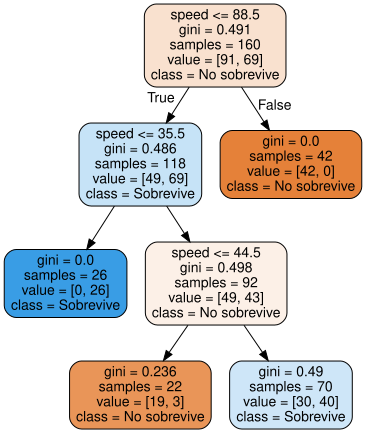

In [69]:
#Visualizar el árbol de decisión
from graphviz import Source
from sklearn import tree
from sklearn.tree import export_graphviz
import os

#Reducimos el número de variables del conjuunto de datos para visualizarlo mejor
X_train_reduced=X_train[['age', 'speed', 'helmet']]
X_test_reduced=X_test[['age', 'speed', 'helmet']]

#Generamos un modelo con el conjunto de datos reducido
clf_tree_reduced = DecisionTreeClassifier(max_depth=3)
clf_tree_reduced.fit(X_train_reduced, y_train)

export_graphviz(
    clf_tree_reduced,
    out_file="tree.dot",
    feature_names=X_train_reduced.columns,
    class_names=['No sobrevive', 'Sobrevive'],
    rounded=True,
    filled=True
)
Source.from_file("tree.dot")

Cuando no es puro, toma la clase que predomina